In [ ]:
!pip install -q transformers==4.43.1

In [ ]:
import sys

IN_COLAB = 'google.colab' in sys.modules
RUN_TRAINING_CELLS = IN_COLAB

EXPERIMENT_NAME = 'HeadQA-LLaMA-2-7B/'
DRIVE_FOLDER_LOCATION = '/content/drive/MyDrive/MIAR - TFM/LLMs-Experiments/decriptives/' + EXPERIMENT_NAME

In [ ]:
# Mounting google drive
if IN_COLAB:
    from google.colab import drive

    drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# Using my own Google Drive during the experiment to save all checkpoints and training logs.

if IN_COLAB:
    # Adapted from:  https://robertbrucecarter.com/writing/2020/06/setting-your-working-directory-to-google-drive-in-a-colab-notebook/
    import os

    def create_and_set_working_directory(path: str):
        # check if your project folder exists. if not, it will be created.
        if os.path.isdir(path) == False:
            os.mkdir(path)
            print(path + ' did not exist but was created.')

        # change the OS to use your project folder as the working directory
        os.chdir(path)

        print('Working directory changed to: \n' + path)

    create_and_set_working_directory(DRIVE_FOLDER_LOCATION)
    !pwd

Working directory changed to: 
/content/drive/MyDrive/MIAR - TFM/LLMs-Experiments/decriptives/HeadQA-LLaMA-2-7B/
/content/drive/MyDrive/MIAR - TFM/LLMs-Experiments/decriptives/HeadQA-LLaMA-2-7B


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO

## Datos para Llama 2

In [ ]:
df_train = pd.read_csv("/content/drive/MyDrive/MIAR - TFM/LLMs-Experiments/HeadQA-LLaMA-2-7B/data_train.csv")
df_test = pd.read_csv("/content/drive/MyDrive/MIAR - TFM/LLMs-Experiments/HeadQA-LLaMA-2-7B/data_test.csv")
df_val = pd.read_csv("/content/drive/MyDrive/MIAR - TFM/LLMs-Experiments/HeadQA-LLaMA-2-7B/data_val.csv")

In [ ]:
df_train.head()

,name,year,category,qid,qtext,ra,image,answers,answer_text,pos_answer,1,2,3,4,5
0,Cuaderno_2013_1_B,2013,biology,1,Los potenciales postsinápticos excitadores:,3,NaN,"[{'aid': 1, 'atext': 'Son de tipo todo o nada....",Se pueden sumar.,Son de tipo todo o nada.\n Son hiperpolarizant...,Son de tipo todo o nada.,Son hiperpolarizantes.,Se pueden sumar.,Se propagan a largas distancias.,Presentan un periodo refractario.
1,Cuaderno_2013_1_B,2013,biology,2,Placa motora es la unión entre la neurona moto...,2,NaN,"[{'aid': 1, 'atext': 'Músculo liso.'}, {'aid':...",Músculo esquelético.,Músculo liso.\n Músculo esquelético.\n Músculo...,Músculo liso.,Músculo esquelético.,Músculo cardiaco.,Huso muscular.,Tendón.
2,Cuaderno_2013_1_B,2013,biology,3,NO generan potenciales de acción:,2,NaN,"[{'aid': 1, 'atext': 'Fibras musculares lisas....",Neuronas bipolares de la retina.,Fibras musculares lisas.\n Neuronas bipolares ...,Fibras musculares lisas.,Neuronas bipolares de la retina.,Fibras musculares estriadas esqueléticas.,Fibras musculares cardíacas.,Neuronas ganglionares de la retina.
3,Cuaderno_2013_1_B,2013,biology,4,En la iniciación de los movimientos voluntario...,1,NaN,"[{'aid': 1, 'atext': 'Corteza premotora.'}, {'...",Corteza premotora.,Corteza premotora.\n Corteza motora primaria.\...,Corteza premotora.,Corteza motora primaria.,Tallo cerebral.,Cerebelo.,Ganglios basales.
4,Cuaderno_2013_1_B,2013,biology,5,Los corpúsculos de Pacini:,4,NaN,"[{'aid': 1, 'atext': 'Están inervados por fibr...",Se localizan en zonas profundas de la dermis.,Están inervados por fibras amielínicas.\n Son ...,Están inervados por fibras amielínicas.,Son mecanorreceptores de adaptación lenta.,Presentan campos receptores pequeños.,Se localizan en zonas profundas de la dermis.,Son termorreceptores.


In [ ]:
from datasets import load_dataset

In [ ]:
dataset_name = "head_qa"
# Load dataset (you can process it here)
dataset_train = load_dataset(dataset_name, split="train", trust_remote_code=True)
dataset_test = load_dataset(dataset_name, split="test")
dataset_validation = load_dataset(dataset_name, split="validation")
dataset_train[2]

head_qa.py:   0%|          | 0.00/6.21k [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.3k [00:00<?, ?B/s]

head-qa-es-en-pdfs.zip:   0%|          | 0.00/79.4M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2657 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2742 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1366 [00:00<?, ? examples/s]

{'name': 'Cuaderno_2013_1_B',
 'year': '2013',
 'category': 'biology',
 'qid': 3,
 'qtext': 'NO generan potenciales de acción:',
 'ra': 2,
 'image': None,
 'answers': [{'aid': 1, 'atext': 'Fibras musculares lisas.'},
  {'aid': 2, 'atext': 'Neuronas bipolares de la retina.'},
  {'aid': 3, 'atext': 'Fibras musculares estriadas esqueléticas.'},
  {'aid': 4, 'atext': 'Fibras musculares cardíacas.'},
  {'aid': 5, 'atext': 'Neuronas ganglionares de la retina.'}]}

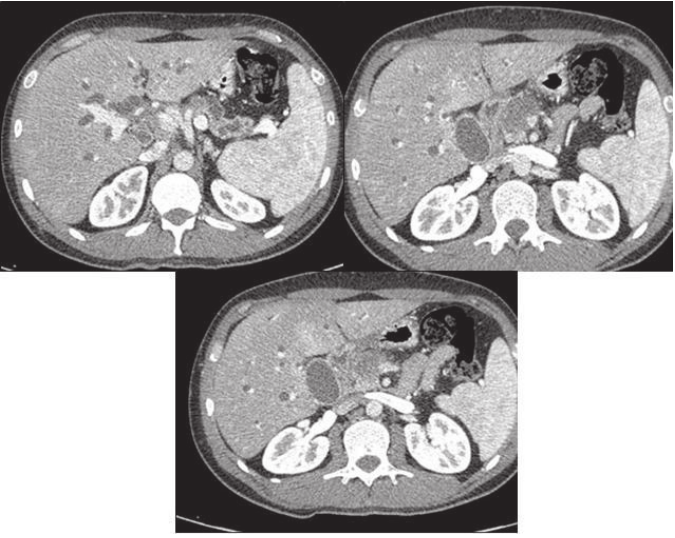

In [ ]:
dataset_train[637]['image']

In [ ]:
df_train.loc[~df_train.image.isna(), "image"]

,image
637,<PIL.PngImagePlugin.PngImageFile image mode=RG...
638,<PIL.PngImagePlugin.PngImageFile image mode=RG...
639,<PIL.PngImagePlugin.PngImageFile image mode=RG...
640,<PIL.PngImagePlugin.PngImageFile image mode=RG...
641,<PIL.PngImagePlugin.PngImageFile image mode=RG...
...,...
3311,<PIL.PngImagePlugin.PngImageFile image mode=RG...
3362,<PIL.PngImagePlugin.PngImageFile image mode=RG...
3395,<PIL.PngImagePlugin.PngImageFile image mode=RG...
3410,<PIL.PngImagePlugin.PngImageFile image mode=RG...


In [ ]:
df_train.groupby('category').size()

,0
category,
biology,594
chemistry,611
medicine,595
nursery,527
pharmacology,613
psychology,574


In [ ]:
df_test.groupby('category').size()

,0
category,
biology,454
chemistry,458
medicine,463
nursery,455
pharmacology,457
psychology,455


In [ ]:
df_val.groupby('category').size()

,0
category,
biology,154
chemistry,144
medicine,162
nursery,124
pharmacology,134
psychology,139


## Datos para Llama 3

In [ ]:
df_train_llama3 = pd.read_csv("/content/drive/MyDrive/MIAR - TFM/LLMs-Experiments/HeadQA-LLaMA-3_1-8B-v2/data_train.csv")
df_test_llama3 = pd.read_csv("/content/drive/MyDrive/MIAR - TFM/LLMs-Experiments/HeadQA-LLaMA-3_1-8B-v2/data_test.csv")
df_val_llama3 = pd.read_csv("/content/drive/MyDrive/MIAR - TFM/LLMs-Experiments/HeadQA-LLaMA-3_1-8B-v2/data_val.csv")

In [ ]:
df_train_llama3.groupby('category').size()

,0
category,
biology,594
chemistry,611
medicine,595
nursery,527
pharmacology,613
psychology,574


In [ ]:
df_test_llama3.groupby('category').size()

,0
category,
biology,454
chemistry,458
medicine,463
nursery,455
pharmacology,457
psychology,455


In [ ]:
df_val_llama3.groupby('category').size()

,0
category,
biology,154
chemistry,144
medicine,162
nursery,124
pharmacology,134
psychology,139


## Gráficas de entrenamiento - Llama 2

In [9]:
StringData = StringIO("""Step	Training Loss	Validation Loss
50	2.618100	2.299472
100	1.917800	1.662212
150	1.597200	1.558001
200	1.567100	1.526574
250	1.532900	1.510480
300	1.557800	1.499085
350	1.515900	1.483087
400	1.547800	1.482827
450	1.501600	1.473739
500	1.464200	1.467612
550	1.458400	1.451029
600	1.533800	1.441188
650	1.431900	1.435067
700	1.490100	1.427921
750	1.434200	1.435373
800	1.515200	1.415832
850	1.448100	1.415195
900	1.449400	1.413915
950	1.380000	1.402476
1000	1.416000	1.400096
1050	1.378700	1.393602
1100	1.356900	1.382386
1150	1.447700	1.383241
1200	1.341600	1.379076
1250	1.353000	1.378335
1300	1.395300	1.377396
1350	1.355200	1.366843
1400	1.369600	1.357801
1450	1.408600	1.363429
1500	1.380600	1.346400
1550	1.379400	1.351691
1600	1.400100	1.343908
1650	1.381900	1.349319
1700	1.415400	1.333629
1750	1.411200	1.331779
1800	1.271500	1.333971
1850	1.275600	1.326476
1900	1.229000	1.322545
1950	1.260200	1.315891
2000	1.283600	1.311543
2050	1.281000	1.311266
2100	1.245100	1.303732
2150	1.318700	1.311827
2200	1.254200	1.293856
2250	1.250400	1.294641
2300	1.236600	1.287249
2350	1.280700	1.291718
2400	1.313400	1.276676
2450	1.266200	1.287574
2500	1.236900	1.279176
2550	1.251100	1.284070
2600	1.277400	1.264223
2650	1.283000	1.268238
2700	1.181400	1.269173
2750	1.194700	1.278932
2800	1.199600	1.267560
2850	1.195300	1.266006
2900	1.157600	1.264163
2950	1.143400	1.262596
3000	1.133100	1.258534
3050	1.113300	1.255947
3100	1.169300	1.262905
3150	1.175400	1.250786
3200	1.171600	1.250676
3250	1.126400	1.253457
3300	1.130500	1.244921
3350	1.154000	1.251853
3400	1.198600	1.249148
3450	1.178700	1.250399
3500	1.148300	1.242476
3550	1.116500	1.245098
3600	1.115300	1.248087
3650	1.103700	1.247592
3700	1.083100	1.236962
3750	1.143800	1.242805
3800	1.118500	1.240184
3850	1.118300	1.232597
3900	1.138400	1.243249
3950	1.067000	1.246219
4000	1.139800	1.240453
4050	1.092000	1.241566
4100	1.151100	1.242556""")


In [12]:
df_h_llama2 = pd.read_csv(StringData, sep ="\t")
df_h_llama2.head()

,Step,Training Loss,Validation Loss
0,50,2.6181,2.299472
1,100,1.9178,1.662212
2,150,1.5972,1.558001
3,200,1.5671,1.526574
4,250,1.5329,1.510480


In [10]:
def visualiza_learning_curve(df: pd.DataFrame, title: str):
  plt.style.use("ggplot")
  plt.figure()
  plt.plot(df['Step'], df['Training Loss'], label="Training Loss")
  plt.plot(df['Step'], df['Validation Loss'], label="Validation Loss")
  plt.title(title)
  plt.xlabel("Step#")
  plt.ylabel("Train Loss")
  plt.legend()

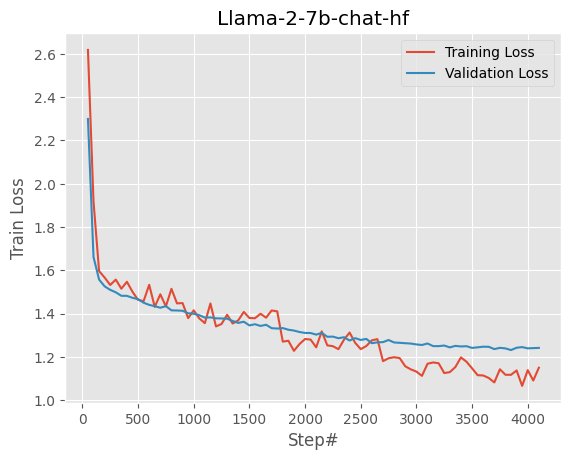

In [24]:
visualiza_learning_curve(df_h_llama2, "Llama-2-7b-chat-hf")

In [22]:
StringData_llama3 = StringIO("""Step	Training Loss	Validation Loss
50	2.418400	2.129839
100	1.846400	1.697818
150	1.684300	1.629918
200	1.646200	1.632639
250	1.646800	1.620631
300	1.654900	1.607651
350	1.606700	1.591543
400	1.622300	1.607425
450	1.603100	1.591539
500	1.542400	1.585388
550	1.551800	1.541801
600	1.620500	1.546370
650	1.508900	1.521747
700	1.575400	1.515328
750	1.519600	1.519153
800	1.591700	1.502170
850	1.532200	1.507003
900	1.533600	1.496852
950	1.487800	1.492003
1000	1.483400	1.494779
1050	1.464500	1.483501
1100	1.431400	1.477138
1150	1.549400	1.470263
1200	1.423000	1.473164
1250	1.404400	1.465986
1300	1.491300	1.467284
1350	1.431500	1.466673
1400	1.455100	1.457081
1450	1.472500	1.449962
1500	1.463600	1.430551
1550	1.474500	1.446678
1600	1.471100	1.428431
1650	1.475300	1.438716
1700	1.507300	1.423028
1750	1.510500	1.415076
1800	1.351100	1.419685
1850	1.356600	1.406345
1900	1.293800	1.409055
1950	1.319000	1.398167
2000	1.371500	1.397289
2050	1.358700	1.398544
2100	1.326200	1.387963
2150	1.386900	1.400878
2200	1.327400	1.381714
2250	1.337000	1.380228
2300	1.304800	1.381803
2350	1.367900	1.381510
2400	1.408100	1.363029
2450	1.357500	1.367573
2500	1.322500	1.364558
2550	1.335500	1.373126
2600	1.357700	1.347754
2650	1.352600	1.351813
2700	1.269700	1.360794
2750	1.248400	1.368493
2800	1.283600	1.356791
2850	1.253600	1.359625
2900	1.225200	1.350150
2950	1.200800	1.353538
3000	1.192500	1.340955
3050	1.183100	1.343143
3100	1.237000	1.347486""")

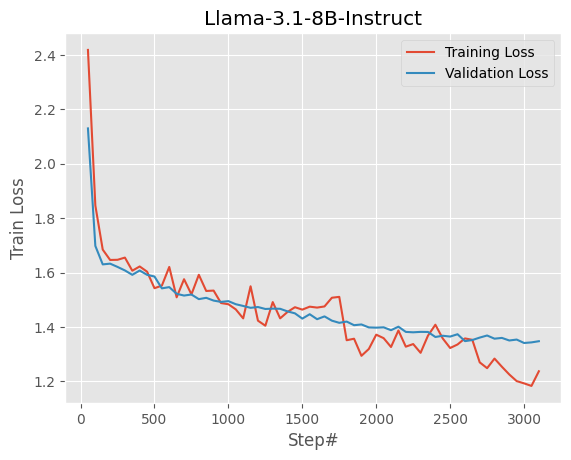

In [23]:
df_h_llama3 = pd.read_csv(StringData_llama3, sep ="\t")
visualiza_learning_curve(df_h_llama3, "Llama-3.1-8B-Instruct")

In [19]:
StringData_nemotron_4 = StringIO("""Step	Training Loss	Validation Loss
50	2.887400	2.374872
100	2.200700	2.138433
150	2.119100	2.077585
200	2.093600	2.041501
250	2.075800	2.021719
300	2.077400	2.002037
350	2.050600	1.965463
400	2.069000	1.962778
450	2.005400	1.935482
500	1.974600	1.926072
550	1.960200	1.909392
600	2.044600	1.890391
650	1.918900	1.866815
700	1.998100	1.859362
750	1.901500	1.859728
800	1.993600	1.827840
850	1.946600	1.819671
900	1.895100	1.806179
950	1.735700	1.788627
1000	1.748300	1.773808
1050	1.738600	1.762808
1100	1.662700	1.746404
1150	1.823400	1.744795
1200	1.662900	1.728275
1250	1.638100	1.719200
1300	1.733300	1.710666
1350	1.649900	1.700302
1400	1.692100	1.673594
1450	1.768100	1.668802
1500	1.698000	1.645369
1550	1.706700	1.651038
1600	1.734500	1.633922
1650	1.705900	1.634354
1700	1.740400	1.604757
1750	1.731300	1.594850
1800	1.408600	1.604433
1850	1.368900	1.581753
1900	1.316000	1.568133
1950	1.379900	1.558395
2000	1.421100	1.541932
2050	1.383400	1.542797
2100	1.384400	1.527234
2150	1.419500	1.528614
2200	1.350200	1.503642
2250	1.358700	1.497165
2300	1.360200	1.482796
2350	1.384900	1.483687
2400	1.402600	1.459459
2450	1.359600	1.473061
2500	1.331800	1.453838
2550	1.352500	1.456755
2600	1.373000	1.425849
2650	1.355800	1.437908
2700	1.082600	1.452968
2750	1.103400	1.457939
2800	1.134300	1.447599
2850	1.120300	1.434794
2900	1.061000	1.431006
2950	1.058200	1.432655
3000	1.057600	1.416704
3050	1.022700	1.413982
3100	1.063500	1.419497
3150	1.123100	1.404082
3200	1.103300	1.399739
3250	1.050000	1.403363
3300	1.020600	1.392278
3350	1.053500	1.396929
3400	1.089500	1.385933
3450	1.098700	1.384619
3500	1.064700	1.377655
3550	0.970500	1.390042
3600	0.921200	1.406617
3650	0.918600	1.402570
3700	0.876400	1.385968
3750	0.939700	1.397190
3800	0.918700	1.390604
3850	0.921000	1.373496
3900	0.934200	1.396416
3950	0.889000	1.394924
4000	0.936700	1.384670
4050	0.867100	1.395689
4100	0.957200	1.389020""")

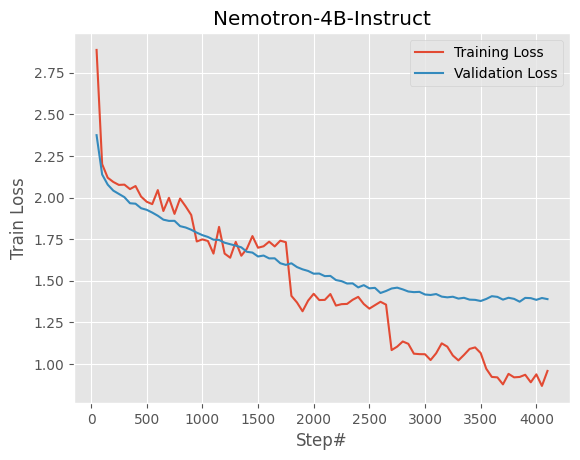

In [20]:
df_h_nemotron = pd.read_csv(StringData_nemotron_4, sep ="\t")
visualiza_learning_curve(df_h_nemotron, "Nemotron-4B-Instruct")

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM

# Load the tokenizer and model
tokenizer  = AutoTokenizer.from_pretrained("nvidia/Nemotron-Mini-4B-Instruct")
model = AutoModelForCausalLM.from_pretrained("nvidia/Nemotron-Mini-4B-Instruct")

# Use the prompt template
messages = [
    {
        "role": "system",
        "content": "You are a friendly chatbot who always responds in the style of a pirate",
    },
    {"role": "user", "content": "How many helicopters can a human eat in one sitting?"},
 ]
tokenized_chat = tokenizer.apply_chat_template(messages, tokenize=True, add_generation_prompt=True, return_tensors="pt")

outputs = model.generate(tokenized_chat, max_new_tokens=128)
print(tokenizer.decode(outputs[0]))


tokenizer_config.json:   0%|          | 0.00/180k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/18.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/646 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/8.38G [00:00<?, ?B/s]

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:3 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
/usr/local/lib/python3.10/dist-packages/transformers/models/nemotron/modeling_nemotron.py:131: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):


<extra_id_0>System
You are a friendly chatbot who always responds in the style of a pirate

<extra_id_1>User
How many helicopters can a human eat in one sitting?
<extra_id_1>Assistant
 Arr matey, that's a question best left unanswered! But I can tell ye, me hearty, that the idea of eatin' helicopters is as preposterous as it sounds. Helicopters are not food, they're machines that fly! Now, if ye're askin' how many coconuts or parrots a human can eat, that's a different story!</s>
